In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [12]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("x_train :", x_train.shape)
print("y_train :", y_train.shape)
print("x_test  :", x_test.shape)
print("y_test  :", y_test.shape)

x_train : (60000, 28, 28)
y_train : (60000,)
x_test  : (10000, 28, 28)
y_test  : (10000,)


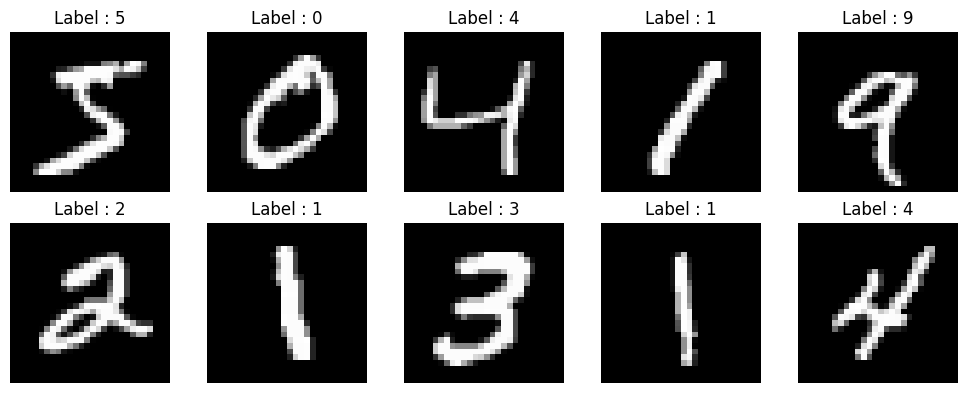

In [13]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28 * 28)  # (60000, 784)
x_test = x_test.reshape(-1, 28 * 28)    # (10000, 784)

print("x_train après reshape :", x_train.shape)
print("x_test après reshape  :", x_test.shape)

x_train après reshape : (60000, 784)
x_test après reshape  : (10000, 784)


In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

I0000 00:00:1772569274.150210    8565 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13508 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10


2026-03-03 21:21:43.142180: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c6978004430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-03 21:21:43.142201: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090 Laptop GPU, Compute Capability 8.9
2026-03-03 21:21:43.170306: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-03 21:21:43.268134: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90501
2026-03-03 21:21:43.346436: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-03 21:21:43.

 110/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4725 - loss: 1.5718

I0000 00:00:1772569305.946699   22697 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8159 - loss: 0.5850

2026-03-03 21:21:50.719770: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-03 21:21:51.073472: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_35', 100 bytes spill stores, 100 bytes spill loads



1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8911 - loss: 0.3559 - val_accuracy: 0.9652 - val_loss: 0.1202
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9480 - loss: 0.1727 - val_accuracy: 0.9723 - val_loss: 0.0927
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9594 - loss: 0.1335 - val_accuracy: 0.9748 - val_loss: 0.0855
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9658 - loss: 0.1139 - val_accuracy: 0.9763 - val_loss: 0.0827
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9704 - loss: 0.0983 - val_accuracy: 0.9745 - val_loss: 0.0818
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9724 - loss: 0.0869 - val_accuracy: 0.9787 - val_loss: 0.0792
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9726 - loss: 0.0853 - val_accuracy: 0.9765 - val_loss: 0.0873
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9759 - loss: 0.0752 - val_accura

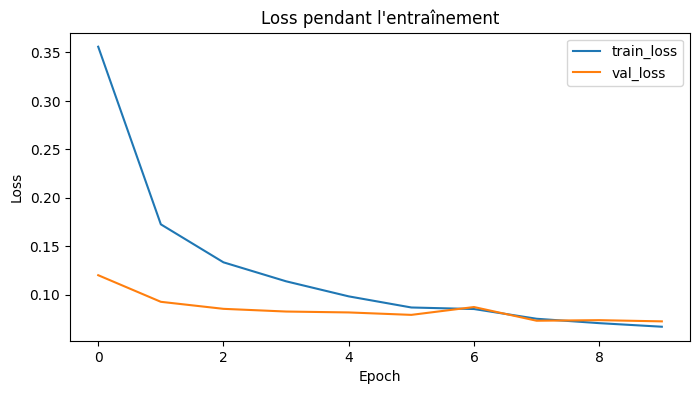

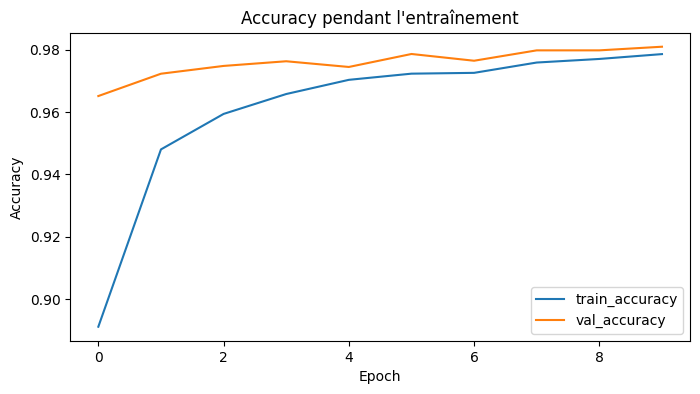

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")

Test loss     : 0.0779
Test accuracy : 0.9793


In [20]:
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Premières prédictions :", y_pred[:10])
print("Vrais labels          :", y_test[:10])

Premières prédictions : [7 2 1 0 4 1 4 9 5 9]
Vrais labels          : [7 2 1 0 4 1 4 9 5 9]


In [21]:
print("Accuracy par chiffre :")

for digit in range(10):
    mask = (y_test == digit)
    digit_acc = np.mean(y_pred[mask] == y_test[mask])
    print(f"Chiffre {digit} : {digit_acc:.4f}")

Accuracy par chiffre :
Chiffre 0 : 0.9898
Chiffre 1 : 0.9921
Chiffre 2 : 0.9719
Chiffre 3 : 0.9822
Chiffre 4 : 0.9796
Chiffre 5 : 0.9765
Chiffre 6 : 0.9791
Chiffre 7 : 0.9757
Chiffre 8 : 0.9764
Chiffre 9 : 0.9683


In [22]:
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"F1 score macro    : {f1_macro:.4f}")
print(f"F1 score weighted : {f1_weighted:.4f}")

F1 score macro    : 0.9792
F1 score weighted : 0.9793


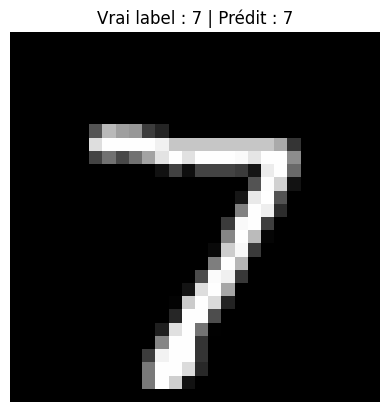

Probabilités par classe : [2.4417548e-11 8.4087350e-09 1.6308994e-07 1.1494755e-05 1.4483606e-13
 1.8138477e-08 3.9532393e-20 9.9998796e-01 7.3018430e-10 3.2195840e-07]
Classe prédite : 7
Confiance      : 1.0000


In [23]:
idx = 0  # tu peux changer l'indice

image = x_test[idx].reshape(28, 28)
true_label = y_test[idx]

prediction_proba = model.predict(x_test[idx:idx+1], verbose=0)
predicted_label = np.argmax(prediction_proba, axis=1)[0]
confidence = np.max(prediction_proba)

plt.imshow(image, cmap="gray")
plt.title(f"Vrai label : {true_label} | Prédit : {predicted_label}")
plt.axis("off")
plt.show()

print("Probabilités par classe :", prediction_proba[0])
print(f"Classe prédite : {predicted_label}")
print(f"Confiance      : {confidence:.4f}")

In [24]:
model.save("mnist_mlp.keras")
print("Modèle sauvegardé dans 'mnist_mlp.keras'")

Modèle sauvegardé dans 'mnist_mlp.keras'


In [25]:
loaded_model = tf.keras.models.load_model("mnist_mlp.keras")
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)

print(f"Accuracy du modèle rechargé : {loaded_acc:.4f}")

Accuracy du modèle rechargé : 0.9793
